In [ ]:
Gender,Married,Education,ApplicantIncome,LoanAmount,CreditHistory,LoanStatus
Male,Yes,Graduate,5000,200,1,Yes
Female,No,Graduate,3000,100,1,Yes
Male,Yes,Not Graduate,2500,120,0,No
Male,No,Graduate,6000,250,1,Yes
Female,Yes,Graduate,4000,150,1,Yes
Male,Yes,Graduate,1500,90,0,No
Female,No,Not Graduate,2000,110,0,No
Male,Yes,Graduate,7000,300,1,Yes
Female,Yes,Graduate,3500,130,1,Yes
Male,No,Not Graduate,1800,100,0,No

In [3]:
import pandas as pd
df=pd.read_csv("load_data.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'load_data.csv'

In [4]:
import pandas as pd

data = {
    "Gender": ["Male","Female","Male","Male","Female","Male","Female","Male","Female","Male"],
    "Married": ["Yes","No","Yes","No","Yes","Yes","No","Yes","Yes","No"],
    "Education": ["Graduate","Graduate","Not Graduate","Graduate","Graduate","Graduate","Not Graduate","Graduate","Graduate","Not Graduate"],
    "ApplicantIncome": [5000,3000,2500,6000,4000,1500,2000,7000,3500,1800],
    "LoanAmount": [200,100,120,250,150,90,110,300,130,100],
    "CreditHistory": [1,1,0,1,1,0,0,1,1,0],
    "LoanStatus": ["Yes","Yes","No","Yes","Yes","No","No","Yes","Yes","No"]
}

df = pd.DataFrame(data)

df.head()

,Gender,Married,Education,ApplicantIncome,LoanAmount,CreditHistory,LoanStatus
0,Male,Yes,Graduate,5000,200,1,Yes
1,Female,No,Graduate,3000,100,1,Yes
2,Male,Yes,Not Graduate,2500,120,0,No
3,Male,No,Graduate,6000,250,1,Yes
4,Female,Yes,Graduate,4000,150,1,Yes


In [5]:
df.shape

(10, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Gender           10 non-null     object
 1   Married          10 non-null     object
 2   Education        10 non-null     object
 3   ApplicantIncome  10 non-null     int64 
 4   LoanAmount       10 non-null     int64 
 5   CreditHistory    10 non-null     int64 
 6   LoanStatus       10 non-null     object
dtypes: int64(3), object(4)
memory usage: 692.0+ bytes


In [7]:
df["LoanStatus"].value_counts()

,count
LoanStatus,
Yes,6
No,4


In [8]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


In [10]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Gender"]=le.fit_transform(df["Gender"])
df["Married"]=le.fit_transform(df["Married"])
df["Education"]=le.fit_transform(df["Education"])
df["LoanStatus"]=le.fit_transform(df["LoanStatus"])
df.head()

,Gender,Married,Education,ApplicantIncome,LoanAmount,CreditHistory,LoanStatus
0,1,1,0,5000,200,1,1
1,0,0,0,3000,100,1,1
2,1,1,1,2500,120,0,0
3,1,0,0,6000,250,1,1
4,0,1,0,4000,150,1,1


In [11]:
print(type(le))

<class 'sklearn.preprocessing._label.LabelEncoder'>


In [12]:
x=df.drop("LoanStatus",axis=1)
y=df["LoanStatus"]

In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)


In [14]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(8, 6)
(2, 6)
(8,)


NameError: name 'test' is not defined

In [17]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(y_pred)

[1 0]


In [19]:
print("predicted:",y_pred)
print("actual:",y_test.values)

predicted: [1 0]
actual: [1 1]


In [22]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print("accuracy:",accuracy)

accuracy: 0.5


In [23]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[0 0]
 [1 1]]


In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.50      0.67         2

    accuracy                           0.50         2
   macro avg       0.50      0.25      0.33         2
weighted avg       1.00      0.50      0.67         2



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


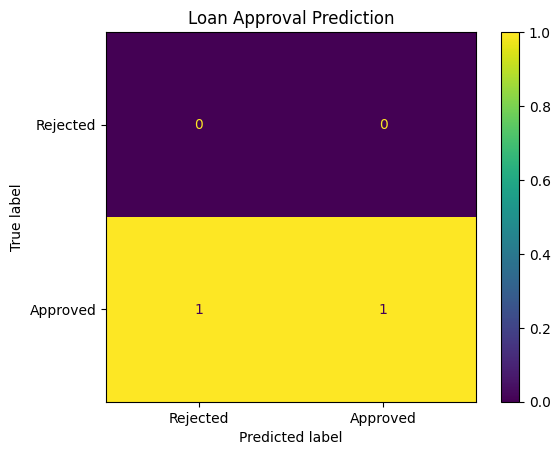

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Rejected","Approved"]
)
plt.title("Loan Approval Prediction")
plt.show()

NameError: name 'pred' is not defined

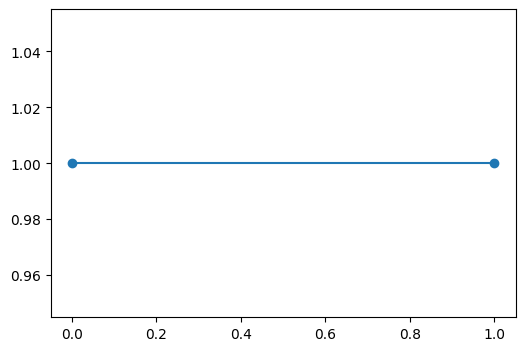

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(y_test.values,marker='o',label="actual")
plt.plot(y-pred,marker="x",label="predicted")
plt.xlabel("test samples")
plt.ylabel("loan status")
plt.title("actual vs predicted")
plt.legend()
plt.show()

In [32]:
import joblib
joblib.dump(model,"loan_model.pkl")

['loan_model.pkl']

In [31]:
%%writefile app.py

import streamlit as st
import joblib
import numpy as np

model = joblib.load("loan_model.pkl")

st.title("Loan Approval Prediction")

gender = st.selectbox("Gender", ["Male", "Female"])
married = st.selectbox("Married", ["Yes", "No"])
education = st.selectbox("Education", ["Graduate", "Not Graduate"])

income = st.number_input("Applicant Income")
loan_amount = st.number_input("Loan Amount")

credit_history = st.selectbox(
    "Credit History",
    [0, 1]
)

gender = 1 if gender == "Male" else 0
married = 1 if married == "Yes" else 0
education = 0 if education == "Graduate" else 1

if st.button("Predict"):

    features = np.array([[
        gender,
        married,
        education,
        income,
        loan_amount,
        credit_history
    ]])

    prediction = model.predict(features)

    if prediction[0] == 1:
        st.success("Loan Approved")
    else:
        st.error("Loan Rejected")

Writing app.py
